### 加载MNIST数据集

In [16]:
import torch                           # PyTorch 核心库，用于张量计算和模型训练
from torchvision import datasets       # 常用图像数据集，如 MNIST、CIFAR-10
from torchvision import transforms     # 图像预处理和数据增强工具
import torch.optim as optim            # 优化器模块，用于更新模型参数

In [17]:
train_data = datasets.MNIST(
    root="C:/Users/tangy/PyCharmMiscProject/Datasets/MNIST",  # 数据集保存路径
    train=True,                       # 加载训练集
    transform=transforms.ToTensor(),  # 将图片转换为 Tensor
    download=True                     # 本地没有数据时自动下载
)
test_data = datasets.MNIST(
    root="C:/Users/tangy/PyCharmMiscProject/Datasets/MNIST",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)

### 数据加载器

In [18]:
batch_size = 64  # 每个批次读取 64 个样本
train_loader = torch.utils.data.DataLoader(
    dataset=train_data,      # 训练数据集
    batch_size=batch_size,   # 每批样本数量
    shuffle=True             # 每轮训练前打乱数据顺序
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_data,       # 测试数据集
    batch_size=batch_size,   # 每批样本数量
    shuffle=False            # 测试时不打乱数据
)

torch.Size([64, 1, 28, 28]) torch.Size([64])


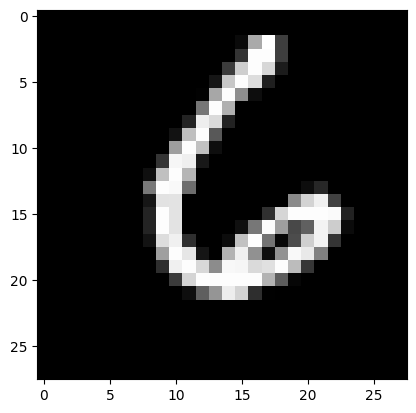

tensor(6)
torch.Size([64, 1, 28, 28]) torch.Size([64])


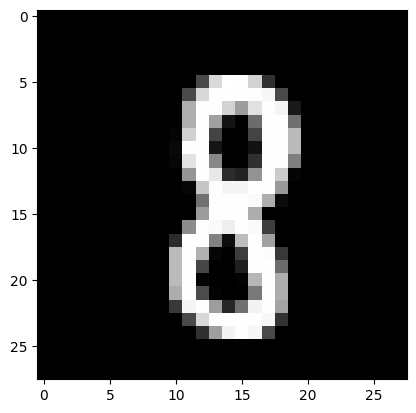

tensor(8)
torch.Size([64, 1, 28, 28]) torch.Size([64])


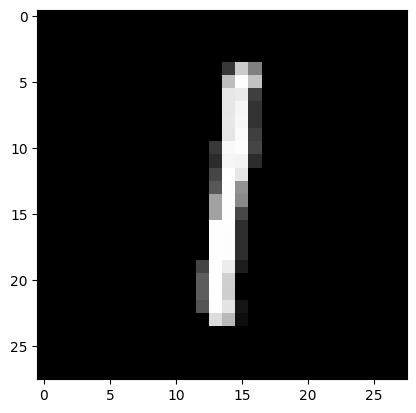

tensor(1)
torch.Size([64, 1, 28, 28]) torch.Size([64])


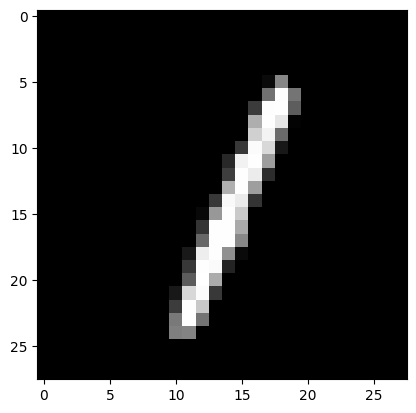

tensor(1)
torch.Size([64, 1, 28, 28]) torch.Size([64])


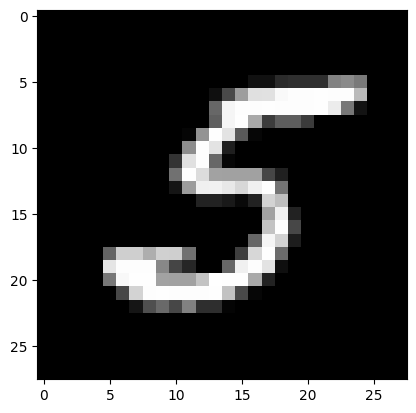

tensor(5)
torch.Size([64, 1, 28, 28]) torch.Size([64])


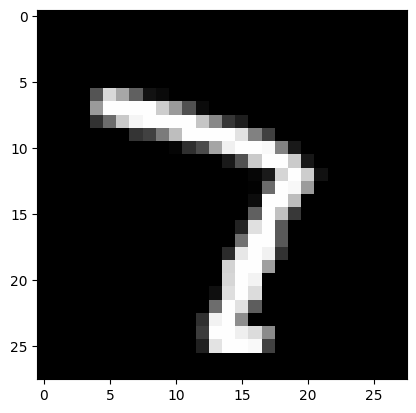

tensor(7)
torch.Size([64, 1, 28, 28]) torch.Size([64])


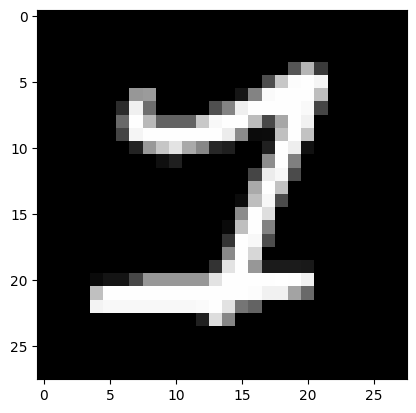

tensor(1)
torch.Size([64, 1, 28, 28]) torch.Size([64])


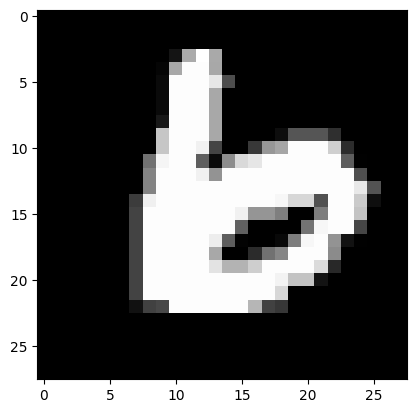

tensor(6)
torch.Size([64, 1, 28, 28]) torch.Size([64])


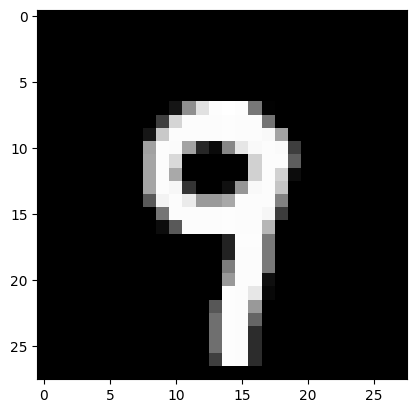

tensor(9)
torch.Size([64, 1, 28, 28]) torch.Size([64])


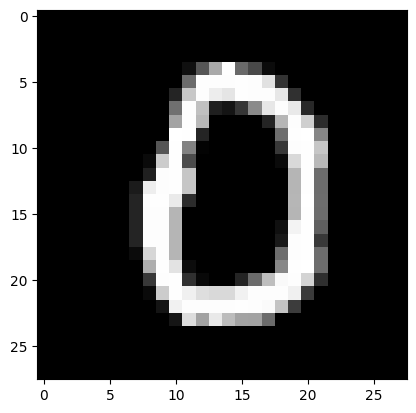

tensor(0)
torch.Size([64, 1, 28, 28]) torch.Size([64])


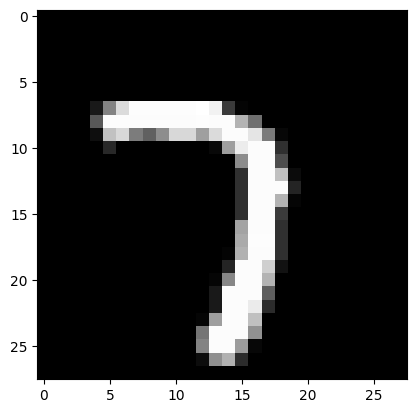

tensor(7)
torch.Size([64, 1, 28, 28]) torch.Size([64])


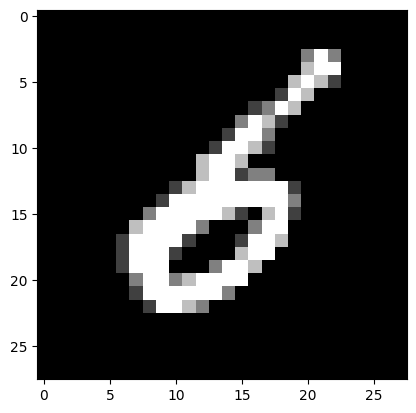

tensor(6)


In [19]:
import matplotlib.pyplot as plt
for i, (images, labels) in enumerate(train_loader):  # 遍历训练数据，每次取得一个 batch
    print(images.shape, labels.shape)                # 查看当前 batch 的图片维度和标签维度
    plt.imshow(images[0][0], cmap='gray')            # 显示当前 batch 中的第一张图片
    plt.show()
    print(labels[0])   # 输出该图片对应的数字标签
    if i > 10:         # 只查看前几个 batch，避免遍历整个数据集
        break

### 构建网络

In [20]:
import torch.nn as nn  # 神经网络模块，用于定义网络层和损失函数

In [21]:
class Model(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()  # 初始化父类 nn.Module
        self.linear = nn.Linear(input_size, output_size)  # 全连接层：将输入特征映射到 10 个类别

    def forward(self, x):  # 定义数据在网络中的前向传播过程
        logits = self.linear(x)
        return logits

In [22]:
input_size = 28*28  # MNIST 图片大小：28 × 28 = 784 个输入特征
output_size = 10    # 10 个数字类别：0～9
model = Model(input_size, output_size)  # 创建模型

### 损失函数和优化器

In [23]:
criterion = nn.CrossEntropyLoss()  # 交叉熵损失函数，用于多分类任务
optimizer = optim.SGD(model.parameters(), lr=0.01)  # SGD 优化器，根据梯度更新模型参数

### 模型评估

In [24]:
def evaluate(model, data_loader):
    model.eval()  # 切换到评估模式
    correct = 0   # 预测正确的样本数量
    total = 0     # 总样本数量
    with torch.no_grad():  # 评估阶段不计算梯度，减少内存和计算开销
        for x, y in data_loader:
            x = x.view(-1, input_size)  # 将 28×28 图片展开为 784 维向量
            logits = model(x)           # 前向传播，得到各类别的预测分数
            _, predicted = torch.max(logits.data, 1)  # 取预测分数最高的类别作为预测结果
            total += y.size(0)  # 累计样本数量
            correct += (predicted == y).sum().item()  # 累计预测正确的样本数量
    return correct / total  # 返回模型准确率

### 模型训练

In [25]:
for epoch in range(10):  # 训练 10 个 epoch
    for images, labels in train_loader:  # 遍历训练集中的每个 batch
        images = images.view(-1, 28 * 28)  # 将 28×28 图片展开为 784 维向量
        labels = labels.long()  # 将标签转换为整数类型

        # 前向传播：计算模型输出和损失
        outputs = model(images)
        loss = criterion(outputs, labels)

        # 反向传播并更新模型参数
        optimizer.zero_grad()   # 清空上一轮的梯度
        loss.backward()         # 计算当前损失对应的梯度
        optimizer.step()        # 根据梯度更新模型参数

    accuracy = evaluate(model, test_loader)  # 每个 epoch 结束后，在测试集上评估准确率

    print(f"Epoch {epoch + 1}: test accuracy = {accuracy:.2f}")  # 输出当前 epoch 的测试准确率

Epoch 1: test accuracy = 0.87
Epoch 2: test accuracy = 0.88
Epoch 3: test accuracy = 0.89
Epoch 4: test accuracy = 0.90
Epoch 5: test accuracy = 0.90
Epoch 6: test accuracy = 0.90
Epoch 7: test accuracy = 0.91
Epoch 8: test accuracy = 0.91
Epoch 9: test accuracy = 0.91
Epoch 10: test accuracy = 0.91
